# Исследование развития индустрии игр в начале XXI века

- Автор: Смирнов Александр Викторович 
- Дата: 23.02.2025

### Цели и задачи проекта

В начале XXI века индустрия игр активно росла: развивались игровые платформы и появлялись мощные консоли (PlayStation 2, Xbox, Nintendo Wii). Возникало множество игровых жанров, а также росло количество многопользовательских онлайн-игр и сообществ. Видеоигры стали считаться важной частью массовой культуры и объединили миллионы людей по всему миру. Исторические данные собраны командой игры "Секреты Темнолесья" из открытых источников. В них есть информация о продажах игр, сделанных в разных жанрах и выпущенных на разных платформах, а также пользовательские и экспертные оценки игр.

#### Цели
- Изучить развитие игровой индустрии с 2000 по 2013 год,
- Провести обзор игровых платформ,
- Изучить объёмы продаж игр разных жанров и
региональные предпочтения игроков с акцентом на играх жанра RPG — в которых игроки управляют персонажами.

####  Задачи
- Познакомиться с данными,
- Проверить их корректность,
- Провести предобработку, получив необходимый срез данных.
- Перед анализом необходимо дополнительно сделать следующее:

- Отобрать данные по времени выхода игры.Нужен период с 2000 по 2013 год включительно.
- Категоризовать игры по оценкам пользователей и экспертов. 
- Выделить три категории:
высокая оценка — с оценкой от 8 до 10 и от 80 до 100, включая правые границы интервалов.
средняя оценка — с оценкой от 3 до 8 и от 30 до 80, не включая правые границы интервалов.
низкая оценка — с оценкой от 0 до 3 и от 0 до 30, не включая правые границы интервалов.
- Выделить топ-7 платформ по количеству игр, выпущенных за весь требуемый период.</font>

### Описание данных

Датасет представлен историческими данными, которые коллеги собрали из открытых источников.
Данные new_games.csv содержат информацию о продажах игр разных жанров и платформ, 
а также пользовательские и экспертные оценки игр:
- Name — название игры.
- Platform — название платформы.
- Year of Release — год выпуска игры.
- Genre — жанр игры.
- NA sales — продажи в Северной Америке (в миллионах проданных копий).
- EU sales — продажи в Европе (в миллионах проданных копий).
- JP sales — продажи в Японии (в миллионах проданных копий).
- Other sales — продажи в других странах (в миллионах проданных копий).
- Critic Score — оценка критиков (от 0 до 100).
- User Score — оценка пользователей (от 0 до 10).
- Rating — рейтинг организации ESRB (англ. Entertainment Software Rating Board
Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию..</font>

### Содержание

1 Загрузка данных и знакомство с ними

2  Проверка ошибок в данных и их предобработка

2.1 Названия, или метки, столбцов датафрейма

2.2 Типы данных

2.3 Наличие пропусков в данных

2.4 Явные и неявные дубликаты в данных

3  Фильтрация данных

4 Категоризация данных

5 Итоговый вывод

## Загрузка данных и знакомство с ними

-Загрузим необходимые библиотеки для анализа данных датасета `new_games.csv`


In [109]:
# Загрузка библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Данные датасета new_games.csv.
df = pd.read_csv('new_games.csv')

# Глянем на данные
df.head(5)

,Name,Platform,Year of Release,Genre,NA sales,EU sales,JP sales,Other sales,Critic Score,User Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [111]:
df.tail(5)

,Name,Platform,Year of Release,Genre,NA sales,EU sales,JP sales,Other sales,Critic Score,User Score,Rating
16951,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.0,0.01,0.0,NaN,NaN,NaN
16952,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.0,0.0,NaN,NaN,NaN
16953,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.0,0.01,0.0,NaN,NaN,NaN
16954,Spirits & Spells,GBA,2003.0,Platform,0.01,0.0,0.0,0.0,NaN,NaN,NaN
16955,Winning Post 8 2016,PSV,2016.0,Simulation,0.00,0.0,0.01,0.0,NaN,NaN,NaN


- Познакомимся с данными: выведем первые строки и результат метода `info()`.


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16956 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16954 non-null  object 
 1   Platform         16956 non-null  object 
 2   Year of Release  16681 non-null  float64
 3   Genre            16954 non-null  object 
 4   NA sales         16956 non-null  float64
 5   EU sales         16956 non-null  object 
 6   JP sales         16956 non-null  object 
 7   Other sales      16956 non-null  float64
 8   Critic Score     8242 non-null   float64
 9   User Score       10152 non-null  object 
 10  Rating           10085 non-null  object 
dtypes: float64(4), object(7)
memory usage: 1.4+ MB


В представленном датасете обьем данных составляет 16956 строк в 11 столбцах, которые соответствуют описанию. Период с 1980 по 2016 г.
В столбцах:
`Name`,
`Year of Release`,
`Genre`, `Critic Score`,
`User Score`,
`Rating` встречаются пропуски. В некоторых значительные, что вероятно также может быть связано с тем что не все игры попали в область внимания пользователей и критиков.

- Year of Release, тип можно изменить, float64 не подходит для даты.
- EU sales и JP sales, а также User Score, нужно изменить тип на float64.

В остальном все в порядке, названия отражают содержимое данных, но лучше их исправить в змеиный регистр.

---

## Проверка ошибок в данных и их предобработка


###  Названия, или метки, столбцов датафрейма

- Выведем названия всех столбцов датафрейма и проверим их стиль написания.
- Приведем все столбцы к стилю snake_case.

In [113]:
df.columns

Index(['Name', 'Platform', 'Year of Release', 'Genre', 'NA sales', 'EU sales',
       'JP sales', 'Other sales', 'Critic Score', 'User Score', 'Rating'],
      dtype='object')

In [114]:
# Преобразуем к стилю snake_case
df.columns = df.columns.str.lower().str.replace(' ', '_')

df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

### 2.2. Типы данных

In [115]:
df_old = df.copy()

print(len(df_old))
df_old.dtypes

16956


name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales            object
jp_sales            object
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object

`year_of_release (Год выпуска)`:
   - Тип данных `float64`. Хотя год можно представить целым числом (`int`), использование типа `float64` может указывать на наличие нецелых значений. Либо это ошибка парсинга данных. 
   
`EU_sales, JP_sales (Продажи в Европе, Японии)`:
   - Для продаж ожидаются числовые значения, однако **EU_sales** и **JP_sales** имеют тип `object`. Возможно, в этих столбцах содержатся не только числа, но и строки (например, пустые значения или какие-то специальные символы вроде `$`, `%` и т.п.).

`user_score (Пользовательская оценка)`:
   - Тип данных `object`, хотя ожидалось бы числовое значение. Здесь тоже возможно наличие строковых значений или символов, обозначающих отсутствие данных (например, `"N/A"`).

In [116]:
df_old['year_of_release'].unique()

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000.,   nan, 1995., 1991., 1981., 1987.,
       1980., 1983.])

`year_of_release (Год выпуска)`:
В годах есть значения nan, поэтому тип данных `float64`. Данные пропуски можно удалить, меньше 2% </font>

In [117]:
df_old['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

`user_score (Пользовательская оценка)`:
   - Тип данных `object`, хотя ожидалось бы числовое значение. Из-за пропусков и значение 'tbd'

`EU_sales, JP_sales (Продажи в Европе, Японии)`:
 - **EU_sales** и **JP_sales** имеют тип `object`,  встречаются строковые значения `unknown` 

In [118]:
df_old['eu_sales'] = pd.to_numeric(df_old['eu_sales'], errors= 'coerce')
df_old['jp_sales'] = pd.to_numeric(df_old['jp_sales'], errors= 'coerce')

df_old['user_score'] = pd.to_numeric(df_old['user_score'], errors= 'coerce')

df_old['year_of_release'] = pd.to_numeric(df_old['year_of_release'], errors='coerce')
df_old['user_score'] = df_old['user_score'].astype('float')

Все цифровые нецелочисленные данные приведены к типу 'float64', при этом строковые значения в этих столбцах были заменены на пропуски.
Значения поля 'year_of_release' приведены к типу 'Int64'
Столбцы 'rating', 'platform', 'genre' имеют ограниченный набор значений и приведены к соответствующему типу 'category'  

### Наличие пропусков в данных

- Посчитаем количество пропусков в каждом столбце в абсолютных и относительных значениях.


In [119]:
temp = df_old.copy()           # Делаем копию текущего датасета

missing = (pd.DataFrame({'Кол-во пропусков': temp.isnull().sum(), 'Доля пропусков': temp.isnull().mean().round(4)})
           .style.background_gradient(cmap='coolwarm'))
missing

,Кол-во пропусков,Доля пропусков
name,2,0.000100
platform,0,0.000000
year_of_release,275,0.016200
genre,2,0.000100
na_sales,0,0.000000
eu_sales,6,0.000400
jp_sales,4,0.000200
other_sales,0,0.000000
critic_score,8714,0.513900
user_score,9268,0.546600


`Столбец name`:
- Пропуски: 2
- Причины: Возможно, название было указан неверно или отсутствует в оригинальной базе данных. Иногда названия могут теряться в процессе сбора данных.

`Столбец year_of_release`:
- Пропуски: 275
- Причины: Год выпуска мог быть неизвестен для некоторых игр, особенно если они были выпущены давно или являются редкими изданиями. Иногда даты могут теряться в процессе сбора данных.

`Столбец genre`:
- Пропуски: 2
- Причины: Жанры игр могли быть неизвестны для небольшого количества записей. Возможно, жанр был указан неверно или отсутствует в оригинальной базе данных.

`Столбец EU_sales`:
- Пропуски: 6
- Причины: Продажи в Европе могли быть не учтены для нескольких игр, возможно, из-за отсутствия релизов в этом регионе или неполных данных о продажах.

`Столбец JP_sales`:
- Пропуски: 4
- Причины: Продажи в Японии также могли быть упущены для отдельных игр, аналогично причинам для Европы.

`Столбец critic_score`:
- Пропуски: 8714
- Причины: Оценки критиков могли быть недоступны для большинства игр, особенно старых или менее известных. Также возможны проблемы с агрегацией данных от разных источников.

`Столбец user_score`:
- Пропуски: 9268
- Причины: Пользовательские оценки могли быть собраны позже или отсутствовали для многих игр, особенно тех, которые уже вышли из активного оборота.

`Столбец rating`:
- Пропуски: 6871
- Причины: Возрастные рейтинги могли быть применены не ко всем играм, особенно к старым или независимым проектам, которые не проходили официальную сертификацию.

Пропуски в полях 'name', 'genre', 'year_of_release' незначительны (не более 1,6 %), предположительно MCAR. Но сами эти поля имеют ключевое значение для исследования. Поэтому принято решение удалить строки с этими пропусками

* Пропуски в полях 'eu_sales', 'jp_sales' можно заменить на средние значения для данной платформы и года выпуска

* столбцы 'critic_score', 'user_score', 'rating'с оценками пользователей, критиков и рейтингом имеют высокую, около половины, долю пропусков, и коррелируют между собой, что может указывать на непопулярность этих игр и не привлечении внимания. Их можно занести в категорию "Нет оценки" 

In [120]:
temp['rating'] = temp['rating'].fillna('Нет данных')
temp['user_score'] = temp['user_score'].fillna('Нет данных')
temp['critic_score'] = temp['critic_score'].fillna('Нет данных')

Об оценке критиков и пользователей, а также рейтинге игр мы ничего не можем судить, поэтому заменим их индикатораими 



In [121]:
temp = temp.dropna(subset= ['year_of_release', 'name', 'year_of_release'])

In [122]:
#заменяем пропуски в столбцах 'jp_sales' и 'eu_sales' на средние значения для данной платформы и года выпуска
grouped = temp.groupby(['platform', 'year_of_release'])
mean_eu_sales = grouped['eu_sales'].transform('mean')
mean_jp_sales = grouped['jp_sales'].transform('mean')
temp['eu_sales'] = temp['eu_sales'].fillna(mean_eu_sales)
temp['jp_sales'] = temp['jp_sales'].fillna(mean_jp_sales)

In [123]:
#проверяем
missing = (pd.DataFrame({'Кол-во пропусков': temp.isnull().sum(), 'Доля пропусков': temp.isnull().mean().round(4)})
           .style.background_gradient(cmap='coolwarm'))
missing

,Кол-во пропусков,Доля пропусков
name,0,0.000000
platform,0,0.000000
year_of_release,0,0.000000
genre,0,0.000000
na_sales,0,0.000000
eu_sales,0,0.000000
jp_sales,0,0.000000
other_sales,0,0.000000
critic_score,0,0.000000
user_score,0,0.000000


Пропусков нет.
- пропуски в столбцах `critic_scorу`, `user_score`,`rating` заменены индикаторами, так как мы не можем судить о субьективных оценочных характеристиках игр, при это число строк с такими пропусками было весьма велико, порядка половины.

- В столбцах `critic_score`, `user_score` заменено на -1, в поле `rating` заменено на `нет данных`,

- Все столбцы с данными о продажах в разных регионах приведены к числовому типу, 

- Пропущенные значения заменены на средние для той же платформы и того же года выпуска игры

- В `eu_sales`, `jp_sales` пропущенные значения заменены на средние

In [124]:
print('количество строк в исходном датасете:', len(df),'\n' 'после обработки пропусков:', len(temp),'\n' 'число удаленных строк:', len(df) - len(temp))

количество строк в исходном датасете: 16956 
после обработки пропусков: 16679 
число удаленных строк: 277


### Явные и неявные дубликаты в данных

In [125]:
df_old_dbl = temp.copy()

In [126]:
#Выведет число уникальных значений по каждому столбцу датафрейма
df_old_dbl.nunique(), len(df_old_dbl)

(name               11426
 platform              31
 year_of_release       37
 genre                 24
 na_sales             401
 eu_sales             313
 jp_sales             248
 other_sales          155
 critic_score          82
 user_score            96
 rating                 9
 dtype: int64,
 16679)

Прежде всего необходимо проверить уникальность значений в категориальных столбцах

In [127]:
print(df_old_dbl['genre'].unique())

df_old_dbl['genre'] = df_old_dbl['genre'].str.lower()

df_old_dbl['genre'].unique()

['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy' 'MISC'
 'ROLE-PLAYING' 'RACING' 'ACTION' 'SHOOTER' 'FIGHTING' 'SPORTS' 'PLATFORM'
 'ADVENTURE' 'SIMULATION' 'PUZZLE' 'STRATEGY']


array(['sports', 'platform', 'racing', 'role-playing', 'puzzle', 'misc',
       'shooter', 'simulation', 'action', 'fighting', 'adventure',
       'strategy'], dtype=object)

In [128]:
print(df_old_dbl['platform'].unique())

df_old_dbl['platform'] = df_old_dbl['platform'].str.upper()

df_old_dbl['platform'].unique()

['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']


array(['WII', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XONE',
       'WIIU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [129]:
df_old_dbl['rating'].unique()

array(['E', 'Нет данных', 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'],
      dtype=object)

In [130]:
df_old_dbl['year_of_release'].unique()

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000., 1995., 1991., 1981., 1987., 1980.,
       1983.])

- После того как нормализуете данные и устраните неявные дубликаты, проверьте наличие явных дубликатов в данных.

In [131]:
print(f'Всего строк {df_old_dbl.shape[0]}')
print(f'Дубликатов {df_old_dbl.duplicated().sum()}')

df_old_dbl = df_old_dbl.drop_duplicates()
print(f'Удалено строк в датасете после обработк {len(df) - len(df_old_dbl)}')
print(f'Осталось {df_old_dbl.shape[0]} строк')

Всего строк 16679
Дубликатов 235
Удалено строк в датасете после обработк 512
Осталось 16444 строк


In [132]:
print(f'Относительное удаление строк: {((len(df) - len(df_old_dbl)) / df.shape[0]) * 100:.2f}%')

df_new = df_old_dbl

Относительное удаление строк: 3.02%


Исходный датасет содержал 16 956 строк, каждая из которых представляла собой запись с различными характеристиками.

После проведения первичной предобработки данных количество строк сократилось до 16 444, что означает удаление 512 строк. Это составляет примерно 3,02% от общего числа записей, что является незначительным процентом потерь.

- Проверка уникальных значений: Выполнена проверка наличия уникальных значений в ключевых полях. Были выявлены и устранены некорректные данные.
- Все значения были приведены к единому регистру (нижнему), чтобы избежать проблем с распознаванием одинаковых записей, различающихся лишь регистрами символов. Этот этап позволил удалить скрытые дубликаты.
- В процессе проверки были обнаружены пропуски в некоторых столбцах, особенно в колонке с рейтингом. Для упрощения дальнейшей работы с этими пропусками был установлен специальный индикатор-заглушка.
-  Названия всех колонок были приведены к общепринятому стилю, что упростит дальнейшую работу с данными и сделает код более читаемым.

Предварительная обработка данных показала, что набор данных достаточно чистый и пригоден для дальнейшего анализа. Потери данных составляют менее 3%. Датасет готов для решения конкретной задачи.

Таким образом, мы привели данные к более чистому состоянию, устранив ошибки в написании и избыточность записей.

---

## Фильтрация данных

Для данного исследования нам нужен период с 2000 по 2013 годы, поэтому сделаем нужный срез

In [133]:
#Создаем копию датасета до фильтрации
df_actual = df_new.copy()

df_actual = df_new[(df_new['year_of_release'] >= 2000) & (df_new['year_of_release'] <= 2013)]

In [134]:
df_actual.head(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,WII,2006.0,sports,41.36,28.96,3.77,8.45,76.0,8.0,E
2,Mario Kart Wii,WII,2008.0,racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,WII,2009.0,sports,15.61,10.93,3.28,2.95,80.0,8.0,E
6,New Super Mario Bros.,DS,2006.0,platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,WII,2006.0,misc,13.96,9.18,2.93,2.84,58.0,6.6,E


In [135]:
df_actual.info(), df_actual.year_of_release.sort_values().unique()

<class 'pandas.core.frame.DataFrame'>
Index: 12781 entries, 0 to 16954
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             12781 non-null  object 
 1   platform         12781 non-null  object 
 2   year_of_release  12781 non-null  float64
 3   genre            12781 non-null  object 
 4   na_sales         12781 non-null  float64
 5   eu_sales         12781 non-null  float64
 6   jp_sales         12781 non-null  float64
 7   other_sales      12781 non-null  float64
 8   critic_score     12781 non-null  object 
 9   user_score       12781 non-null  object 
 10  rating           12781 non-null  object 
dtypes: float64(5), object(6)
memory usage: 1.2+ MB


(None,
 array([2000., 2001., 2002., 2003., 2004., 2005., 2006., 2007., 2008.,
        2009., 2010., 2011., 2012., 2013.]))

In [136]:
print('В результате обработки и фильтрации датасета получили следующие показатели:', '\n'
    'Было строк в исходном датасете:', len(df),'\n'
      'Осталось строк в датасете после отбаботки:', len(df_actual), '\n'
      'Удалено строк в датасете после обработки:', len(df)-len(df_actual), '\n'
      'Процент потерь:', round(100 - (len(df_actual)/len(df))*100,2)
     )

В результате обработки и фильтрации датасета получили следующие показатели: 
Было строк в исходном датасете: 16956 
Осталось строк в датасете после отбаботки: 12781 
Удалено строк в датасете после обработки: 4175 
Процент потерь: 24.62


В результате обработки имеем 2 датасета:

Датасет df_new - все данные обработанные на пропуски и дубликаты

Датасет df_actual - данные обработанные на пропуски и дубликаты и отфильтрованные по временному периоду с 2000 по 2013 г.

---

### Категоризируем все игры по оценкам пользователей: 

высокая оценка (от 8 до 10 включительно), 

средняя оценка (от 3 до 8, не включая правую границу интервала) и 

низкая оценка (от 0 до 3, не включая правую границу интервала).

In [137]:
df_actual.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12781 entries, 0 to 16954
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             12781 non-null  object 
 1   platform         12781 non-null  object 
 2   year_of_release  12781 non-null  float64
 3   genre            12781 non-null  object 
 4   na_sales         12781 non-null  float64
 5   eu_sales         12781 non-null  float64
 6   jp_sales         12781 non-null  float64
 7   other_sales      12781 non-null  float64
 8   critic_score     12781 non-null  object 
 9   user_score       12781 non-null  object 
 10  rating           12781 non-null  object 
dtypes: float64(5), object(6)
memory usage: 1.2+ MB


#### Выводим распределение числа игр по оценкам пользователей

In [138]:
# Преобразуем в числа, нечисловые значения станут NaN
df_actual['user_score'] = pd.to_numeric(df_actual['user_score'], errors='coerce')

df_actual['user_group_score'] = pd.cut(df_actual['user_score'], bins= [0, 3, 8, 10], labels= ['Низкая оценка', 'Средняя оценка', 'Высокая оценка'], right= False).astype('str')

df_actual['user_group_score'] = df_actual['user_group_score'].replace('nan', 'Без оценки')

df_user = (df_actual.groupby(['user_group_score'])['name'].count()).sort_values(ascending = False).reset_index()

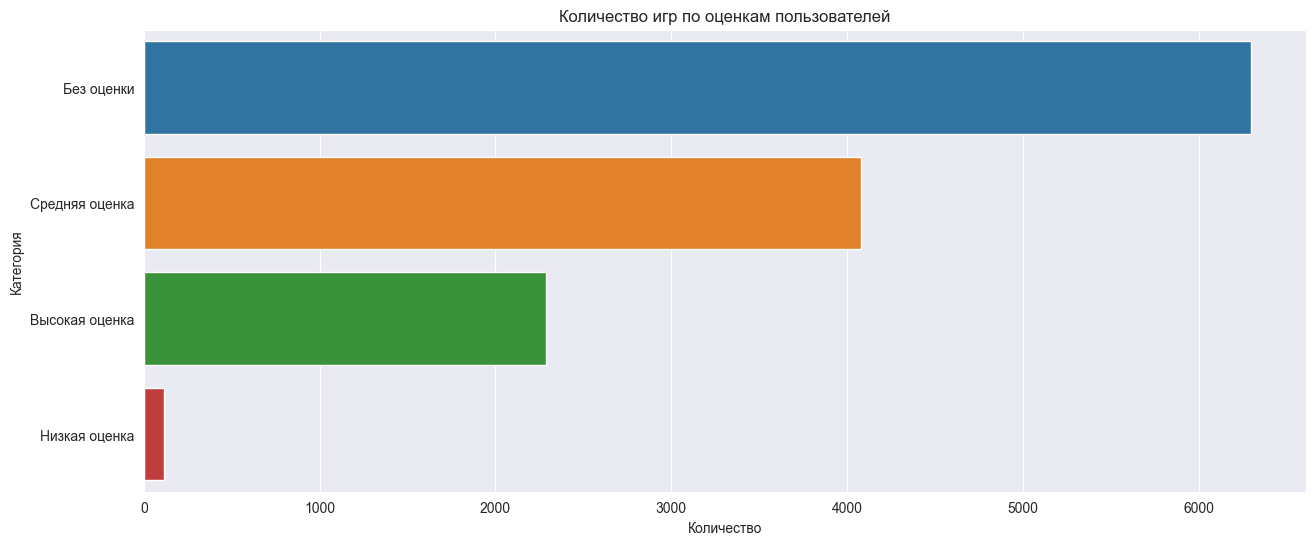

In [139]:
plt.figure(figsize= (15, 6))

sns.set_style('darkgrid')

sns.barplot(data= df_user, x= 'name', y= 'user_group_score', hue= 'user_group_score')

plt.title('Количество игр по оценкам пользователей')
plt.xlabel('Количество')
plt.ylabel('Категория')

plt.show()

### Категоризируем все игры по оценкам критиков

- высокая оценка (от 80 до 100 включительно),
- средняя оценка (от 30 до 80, не включая правую границу интервала) и
- низкая оценка (от 0 до 30, не включая правую границу интервала).

In [140]:
# Преобразуем в числа, нечисловые значения станут NaN
df_actual['critic_score'] = pd.to_numeric(df_actual['critic_score'], errors='coerce')

df_actual['critic_group_score'] = pd.cut(df_actual['critic_score'], bins= [0, 30, 80, 100], labels= ['Низкая оценка', 'Средняя оценка', 'Высокая оценка'], right= False).astype('str')

df_actual['critic_group_score'] = df_actual['critic_group_score'].replace('nan', 'Без оценки')

df_critic = (df_actual.groupby(['critic_group_score'])['name'].count()).sort_values(ascending = False).reset_index()

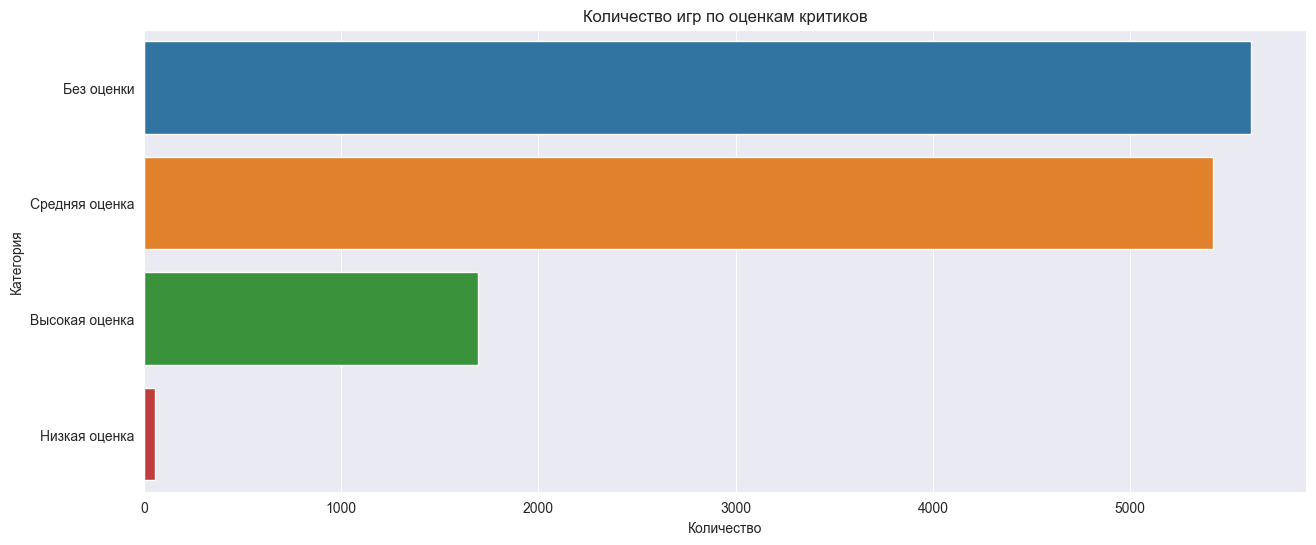

In [141]:
plt.figure(figsize= (15, 6))

sns.set_style('darkgrid')

sns.barplot(data= df_critic, x= 'name', y= 'critic_group_score', hue= 'critic_group_score')

plt.title('Количество игр по оценкам критиков')
plt.xlabel('Количество')
plt.ylabel('Категория')

plt.show()

### Выделяем топ-7 платформ по количеству игр, выпущенных за весь актуальный период.


In [142]:
platform_top = df_actual.groupby('platform')['name'].count().sort_values(ascending= False).reset_index().head(7)

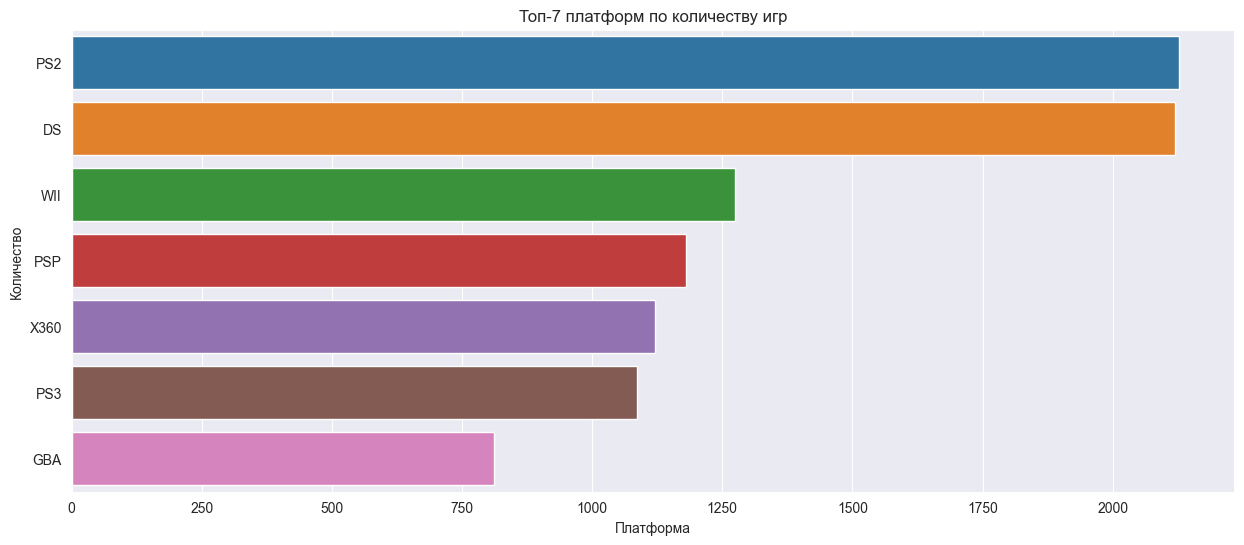

In [143]:
plt.figure(figsize= (15, 6))

sns.set_style('darkgrid')

sns.barplot(data= platform_top, x= 'name', y= 'platform', hue= 'platform')

plt.title('Топ-7 платформ по количеству игр')
plt.xlabel('Платформа')
plt.ylabel('Количество')

plt.show()

---

## Выводы

Данный анализ проводился для статьи-исследования команды разработчиков "Секреты темнолесья" с целью изучить объёмы продаж игр разных жанров и региональные предпочтения игроков.

- Начальный обьем данных составлял 16956 строк в 11 столбцах.
- Для данного исследования был сделан срез по периоду с 2000 до 2013 год.
- Все поля с данными были приведены к соответствующим типам.
- В датасете были обработаны и заполнены пропуски в количестве 199, удален 1 дубликат. 
- Число строк в обработанном датафрейме составило 12781 строк 
- Эти данные позволяют сделать более детальный анализ развития игровой индустрии за указанный период.
- Была проведена категоризация по оценкам пользователей и критиков и добавлены соответствующие поля в актуальный датасет.
- Например выделен топ -7 наиболее популярных платформ
- Распределение числа игр по категориям оценок пользователей и критиков